# 04. How wind and solar shape electricity prices in Portugal

In [1]:
# Import the libraries and open the database
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

connection = sqlite3.connect("../data/electricity.db")

In [2]:
# Join prices and production for each date and hour
query = """
SELECT p.date, p.hour, p.price_pt,
       r.consumption, r.solar, r.wind, r.hydro, r.natural_gas
FROM prices AS p
JOIN production AS r
  ON p.date = r.date AND p.hour = r.hour
"""
df = pd.read_sql(query, connection)

# Year and share of consumption covered by wind and solar (%)
df["year"] = df["date"].str[:4].astype(int)
df["renewable_share"] = (df["wind"] + df["solar"]) / df["consumption"] * 100
print(len(df), "hours with both price and production")

67928 hours with both price and production


## 1. More wind and solar, lower prices (the merit order effect)

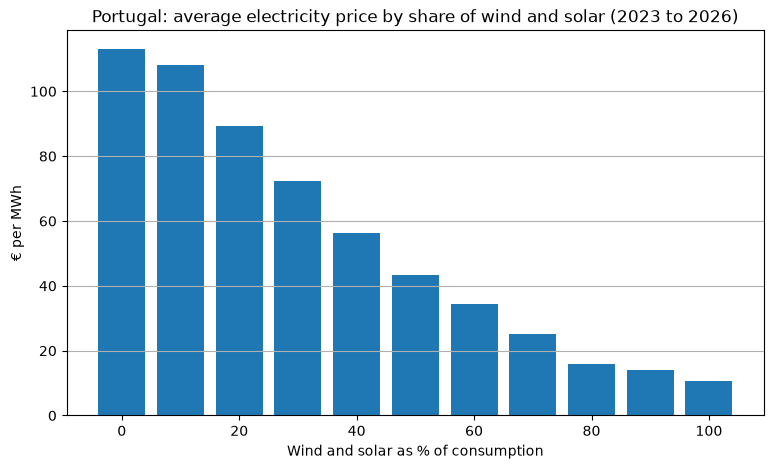

In [3]:
# Average price by share of consumption covered by wind and solar, in groups of 10 points (2023 onwards)
df["share_group"] = ((df["renewable_share"] // 10) * 10).clip(upper=100)
by_share = df[df["year"] >= 2023].groupby("share_group")["price_pt"].mean()

plt.figure(figsize=(9, 5))
plt.bar(by_share.index, by_share.values, width=8)
plt.title("Portugal: average electricity price by share of wind and solar (2023 to 2026)")
plt.xlabel("Wind and solar as % of consumption")
plt.ylabel("€ per MWh")
plt.grid(True, axis="y")
plt.savefig("../figures/price_by_renewable_share.png")
plt.show()

## 2. The duck curve: prices by hour of the day

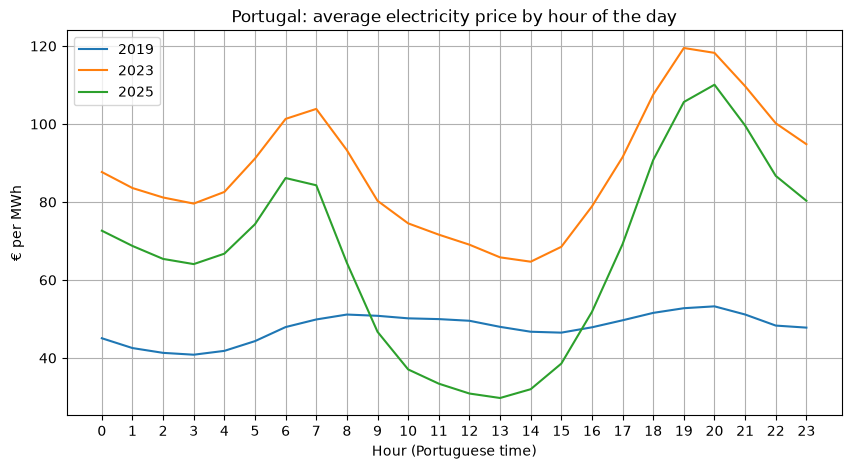

In [4]:
# Average price by hour of the day in 2019, 2023 and 2025
plt.figure(figsize=(10, 5))
for year in [2019, 2023, 2025]:
    by_hour = df[df["year"] == year].groupby("hour")["price_pt"].mean()
    plt.plot(by_hour.index, by_hour.values, label=str(year))
plt.title("Portugal: average electricity price by hour of the day")
plt.xlabel("Hour (Portuguese time)")
plt.ylabel("€ per MWh")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.savefig("../figures/duck_curve.png")
plt.show()